# Baseline Model - Financial Complaint Classification

This notebook trains a first supervised model for classifying complaint narratives into financial product categories.

The goal is not to build the final model yet. The goal is to create a clear baseline that can be improved later.

## Baseline approach

- Clean missing or empty complaint narratives
- Use a stratified train/test split
- Convert text into TF-IDF features
- Train a class-weighted Linear SVM
- Evaluate with class-aware metrics
- Review errors with a confusion matrix and misclassified examples

## 1. Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Data

The notebook expects `complaints_processed.csv` to be in the project root, one level above the `notebooks/` folder.

In [2]:
data_path = '../complaints_processed.csv'

df = pd.read_csv(data_path, index_col=0)
df.columns = df.columns.str.lower()
df = df[['product', 'narrative']].copy()

print(df.shape)
df.head()

(162421, 2)


,product,narrative
0,credit_card,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company ...
1,credit_card,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card...
2,retail_banking,forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actually opened account s...
3,credit_reporting,payment history missing credit report specialized loan servicing sl made mistake put account forbearance without authorization knowledge...
4,credit_reporting,payment history missing credit report made mistake put account forbearance without authorization knowledge matter fact automatic payment...


## 3. Basic Cleaning

The baseline removes missing or empty complaint narratives. It also removes exact duplicate narrative text before the train/test split. This avoids data leakage where the same complaint text could appear in both training and test data.

In [3]:
model_data = df.dropna(subset=['product', 'narrative']).copy()
model_data['narrative'] = model_data['narrative'].astype(str).str.strip()
model_data = model_data[model_data['narrative'].ne('')].copy()

rows_before_dedup = len(model_data)
model_data = model_data.drop_duplicates(subset='narrative').copy()
duplicates_removed = rows_before_dedup - len(model_data)

print('Rows after cleaning:', len(model_data))
print('Exact duplicate narratives removed:', duplicates_removed)
print('Product categories:', model_data['product'].nunique())

display(
    model_data['product']
    .value_counts()
    .rename_axis('product')
    .reset_index(name='complaints')
)

Rows after cleaning: 124472
Exact duplicate narratives removed: 37939
Product categories: 5


,product,complaints
0,credit_reporting,56240
1,debt_collection,21057
2,mortgages_and_loans,18723
3,credit_card,14983
4,retail_banking,13469


## 4. Train/Test Split

A stratified split keeps the same class proportions in the training and test sets. This matters because the dataset is imbalanced.

In [4]:
X = model_data['narrative']
y = model_data['product']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print('Train rows:', len(X_train))
print('Test rows:', len(X_test))

split_check = pd.DataFrame({
    'train_pct': (y_train.value_counts(normalize=True) * 100).round(2),
    'test_pct': (y_test.value_counts(normalize=True) * 100).round(2),
})
display(split_check)

Train rows: 99577
Test rows: 24895


,train_pct,test_pct
product,,
credit_reporting,45.18,45.18
debt_collection,16.92,16.92
mortgages_and_loans,15.04,15.04
credit_card,12.04,12.04
retail_banking,10.82,10.82


## 5. Train Baseline Model

TF-IDF is a strong baseline for text classification because it gives more weight to terms that are important in a document but not too common across all documents.

Linear SVM is used because it usually performs well on sparse text features. `class_weight='balanced'` helps reduce the impact of the majority class.

In [5]:
baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.90,
        max_features=50000,
        stop_words='english',
    )),
    ('clf', LinearSVC(class_weight='balanced', random_state=42)),
])

baseline_model.fit(X_train, y_train)
print('Baseline model trained')

Baseline model trained


## 6. Evaluate Model

For this dataset, macro F1 and per-class recall are more useful than accuracy alone because the class sizes are not balanced.

In [6]:
y_pred = baseline_model.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).T

display(report_df.round(3))
print(classification_report(y_test, y_pred))

,precision,recall,f1-score,support
credit_card,0.785,0.810,0.797,2997.000
credit_reporting,0.909,0.879,0.894,11248.000
debt_collection,0.789,0.791,0.790,4211.000
mortgages_and_loans,0.841,0.869,0.855,3745.000
retail_banking,0.846,0.890,0.868,2694.000
accuracy,0.856,0.856,0.856,0.856
macro avg,0.834,0.848,0.841,24895.000
weighted avg,0.857,0.856,0.856,24895.000


                     precision    recall  f1-score   support

        credit_card       0.78      0.81      0.80      2997
   credit_reporting       0.91      0.88      0.89     11248
    debt_collection       0.79      0.79      0.79      4211
mortgages_and_loans       0.84      0.87      0.85      3745
     retail_banking       0.85      0.89      0.87      2694

           accuracy                           0.86     24895
          macro avg       0.83      0.85      0.84     24895
       weighted avg       0.86      0.86      0.86     24895



## 7. Confusion Matrix

The confusion matrix shows where the model confuses product categories. This is useful for deciding what to improve next.

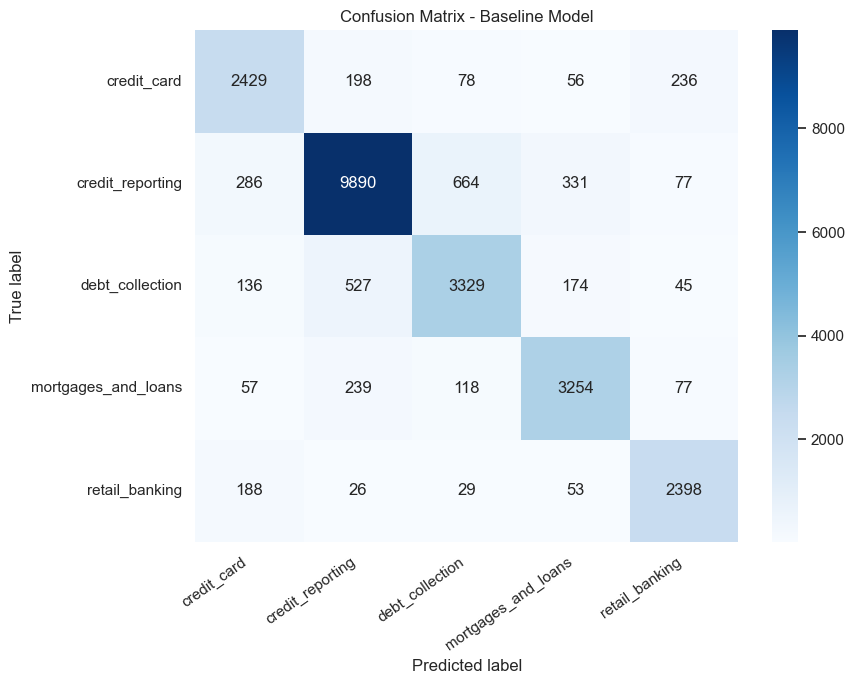

In [7]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Baseline Model')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Error Review

A few misclassified examples help show where the baseline needs more work. This is more useful than only looking at aggregate metrics.

In [8]:
errors = pd.DataFrame({
    'narrative': X_test,
    'actual': y_test,
    'predicted': y_pred,
})
errors = errors[errors['actual'] != errors['predicted']].copy()

print('Misclassified complaints:', len(errors))
print('Error rate:', round(len(errors) / len(X_test) * 100, 2), '%')

display(errors.sample(min(10, len(errors)), random_state=42))

Misclassified complaints: 3595
Error rate: 14.44 %


,narrative,actual,predicted
152820,advised nationwide loan consultant longer working confirmed correspondence hear application specialist today company advising would chec...,credit_reporting,debt_collection
50410,client honda financial since month hospitalized get emergency got hospital go honda financial attempted call old phone number hadnt rece...,credit_reporting,mortgages_and_loans
112515,purchased game son prior leaving babysitter went town weekend arrived destination credit card wouldnt work found son somehow charged ont...,retail_banking,credit_card
45556,agree settlement company settle debt told submit payment online system tried would let tried submitting payment twice found strange subm...,debt_collection,mortgages_and_loans
33084,victim identity theft someone used social get medical care another account name,credit_reporting,debt_collection
46190,paid loan successfully full loan amount credit report state santander usa reported amount charged paid le remaining balance also payment...,mortgages_and_loans,credit_reporting
114603,contacted regarding account inquired continuation program agent informed eligible told making payment optional advised next payment due ...,credit_card,credit_reporting
12461,company fraudulently charging applying extra payment overcharging account amount late fee never knowledge day spoke advised late fee acc...,mortgages_and_loans,credit_card
82200,payment plan american express agreed would draft every month early paid card full received letter american express stating completed pay...,credit_card,debt_collection
117782,received debit card via usps paypal sign account authorize account set name ever plan business paypal account opened fraudulently person...,credit_card,retail_banking


## 9. Takeaways

This baseline gives a first benchmark for the project. The most important next step is to inspect the weakest classes and the most common confusion pairs.

Possible improvements:

- Tune TF-IDF settings and regularization
- Compare Logistic Regression and Linear SVM
- Try character n-grams for noisy text
- Remove exact duplicates before splitting if leakage is suspected
- Add a dedicated error-analysis section for the most confused class pairs